In [ ]:
import sys; sys.path += ['./../']
import numpy as np
from CardamomOT import train_classifier, predict_cell_types, plot_cell_type_proportions
import anndata as ad
import matplotlib.pyplot as plt
import os
import pandas as pd

label="cell_type"

# Name of the file where are the data
p_DO = './../experimental_datasets/Kameneva/'
p_S =  './../experimental_datasets/Schiebinger/'
p_Sem = "./../experimental_datasets/Semrau/"
p_all = './../collaborations/copycat/RMS_all/'  
p_136 = './../collaborations/copycat/RD136/' 
p_v3 = './../collaborations/copycat/RMS2V3/'  
p_10 = './../collaborations/copycat/RMS10/' 

stim = 1.0
prior= 1.0

def compare_cell_types(p, perturb_name, split='train'):
    """
    Compare les types cellulaires avant/après une perturbation combinée (KO/OV).
    `perturb_name` peut être un label de type:
      - "KO_HSPA1B_OV_0"
      - "combo_1_KO_HSPA1B-COL64A2_OV_HSPA1B"
    """

    # --- Chargement des données principales
    adata_full = ad.read_h5ad(os.path.join(p, 'Data', f'data_{split}.h5ad'))
    adata_sim = ad.read_h5ad(os.path.join(p, f'cardamomOT/adata_sim_stim{stim}_prior{prior}.h5ad'))

    # --- Chargement de la simulation combinée
    adata_perturb_path = os.path.join(
        p, f'cardamomOT/adata_sim_{perturb_name}_stim{stim}_prior{prior}.h5ad'
    )

    if not os.path.exists(adata_perturb_path):
        raise FileNotFoundError(f"⚠️ Fichier {adata_perturb_path} introuvable.")
    
    adata_perturb = ad.read_h5ad(adata_perturb_path)
    print(f"📂 Lecture : {adata_perturb_path}")

    # --- Entraînement du classifieur sur les données réelles
    clf = train_classifier(adata_full, label_key=label)
    adata_sim_full = predict_cell_types(adata_sim, clf, label_key=label)

    # --- Identifier les gènes à modifier
    # Exemple : "combo_1_KO_HSPA1B-COL64A2_OV_HSPA1B"
    name_parts = perturb_name.split('_')
    ko_genes, ov_genes = [], []

    if "KO" in name_parts:
        ko_idx = name_parts.index("KO")
        # tout jusqu’à OV ou fin
        for g in name_parts[ko_idx + 1:]:
            if g == "OV": break
            if g not in ["none", "0"]:
                ko_genes.extend(g.split('-'))

    if "OV" in name_parts:
        ov_idx = name_parts.index("OV")
        for g in name_parts[ov_idx + 1:]:
            if g not in ["none", "0"]:
                ov_genes.extend(g.split('-'))

    perturbed_genes = list(set(ko_genes + ov_genes))
    print(f"🧬 Gènes perturbés détectés : {perturbed_genes}")

    # --- Créer une version "simulée modifiée"
    adata_sim_modif = adata_sim.copy()

    for gene in perturbed_genes:
        if gene not in adata_full.var_names:
            print(f"⚠️ Gène {gene} introuvable dans adata_full, ignoré.")
            continue

        cnt = np.where(adata_full.var_names == gene)[0][0]
        print(f"🔄 Remplacement des valeurs simulées pour {gene}")
        print(f"Avant : mean={np.mean(adata_sim_modif.X[:, cnt]):.3f}, Après : mean={np.mean(adata_perturb.X[:, cnt]):.3f}")
        adata_sim_modif.X[:, cnt] = adata_perturb.X[:, cnt]

    # --- Prédictions des types cellulaires
    adata_sim_modif = predict_cell_types(adata_sim_modif, clf, label_key=label)
    adata_perturb = predict_cell_types(adata_perturb, clf, label_key=label)

    adata_perturb.write(p+f'cardamomOT/adata_sim_{perturb_name}_stim{stim}_prior{prior}.h5ad')

    cmap_cat = plt.get_cmap('Dark2')
    cats = adata_full.obs["cell_type"].astype(str).unique().tolist()
    colors = [cmap_cat(i % 20) for i in range(len(cats))]

    # --- Visualisation
    prop_df = plot_cell_type_proportions(
        adatas=[adata_full, adata_sim_full, adata_sim_modif, adata_perturb],
        labels=["data", "sim wt", "sim single", "sim perturb"],
        label_key=label, colors=colors
    )
    prop_df.to_csv('prop_df', index=False)



[autoreload of joblib._utils failed: Traceback (most recent call last):
  File "/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 621, in superreload
    update_generic(old_obj, new_obj)
  File "/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 447, in update_generic
    update(a, b)
  File "/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 359, in update_function
    setattr(old, name, getattr(new, name))
ValueError: eval_() requires a code object with 0 free vars, not 2
]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


📂 Lecture : ./../experimental_datasets/Kameneva/cardamomOT/adata_sim_KO_CHGA_OV_STMN2_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['CHGA', 'STMN2']
🔄 Remplacement des valeurs simulées pour CHGA
Avant : mean=25.829, Après : mean=0.421
🔄 Remplacement des valeurs simulées pour STMN2
Avant : mean=14.237, Après : mean=33.157


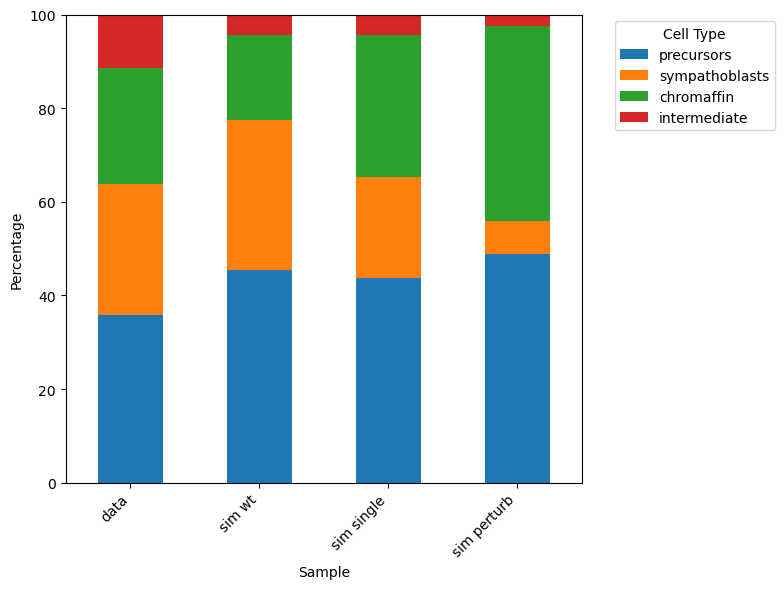

cell_type    precursors  sympathoblasts  chromaffin  intermediate
data          35.722222       28.055556   24.722222     11.500000
sim wt        45.444444       31.944444   18.222222      4.388889
sim single    43.666667       21.722222   30.333333      4.277778
sim perturb   48.888889        6.944444   41.666667      2.500000
📂 Lecture : ./../experimental_datasets/Kameneva/cardamomOT/adata_sim_KO_CHGA_OV_none_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['CHGA']
🔄 Remplacement des valeurs simulées pour CHGA
Avant : mean=25.829, Après : mean=0.435


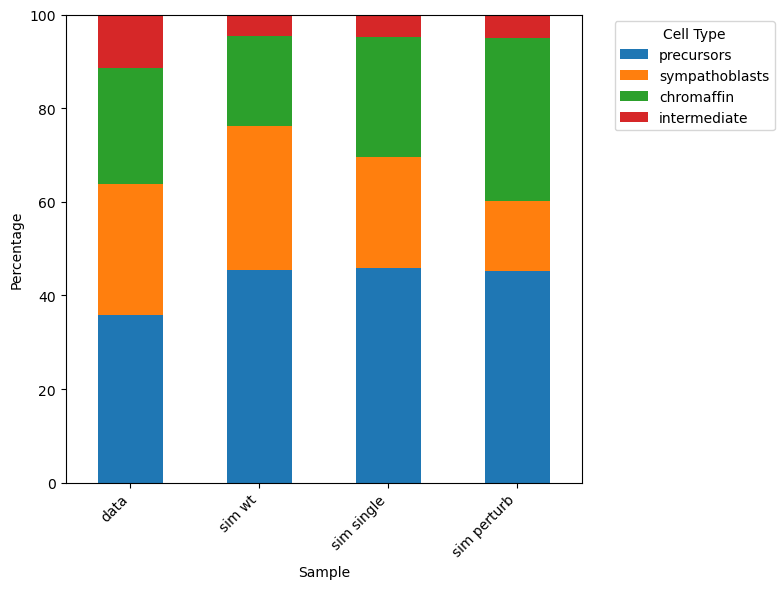

cell_type    precursors  sympathoblasts  chromaffin  intermediate
data          35.722222       28.055556   24.722222     11.500000
sim wt        45.388889       30.722222   19.388889      4.500000
sim single    45.833333       23.777778   25.500000      4.888889
sim perturb   45.222222       14.944444   34.722222      5.111111
📂 Lecture : ./../experimental_datasets/Kameneva/cardamomOT/adata_sim_KO_none_OV_STMN2_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['STMN2']
🔄 Remplacement des valeurs simulées pour STMN2
Avant : mean=14.237, Après : mean=33.372


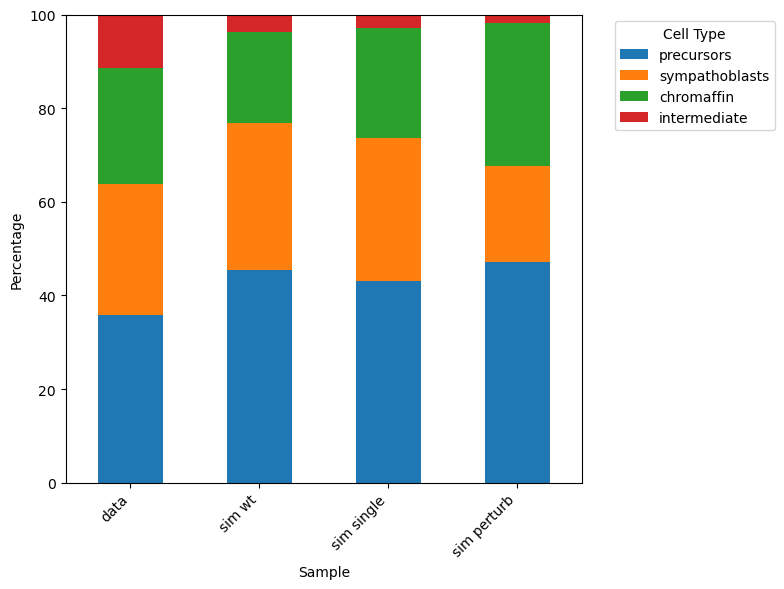

cell_type    precursors  sympathoblasts  chromaffin  intermediate
data          35.722222       28.055556   24.722222     11.500000
sim wt        45.500000       31.333333   19.444444      3.722222
sim single    43.055556       30.500000   23.611111      2.833333
sim perturb   47.222222       20.388889   30.555556      1.833333
📂 Lecture : ./../experimental_datasets/Kameneva/cardamomOT/adata_sim_KO_none_OV_S100B_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['S100B']
🔄 Remplacement des valeurs simulées pour S100B
Avant : mean=4.122, Après : mean=21.255


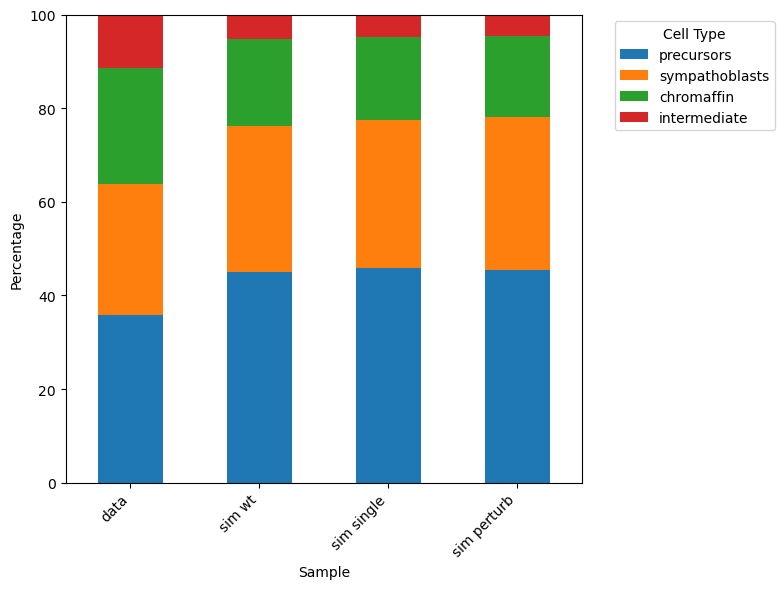

cell_type    precursors  sympathoblasts  chromaffin  intermediate
data          35.722222       28.055556   24.722222     11.500000
sim wt        44.888889       31.333333   18.444444      5.333333
sim single    45.944444       31.444444   17.722222      4.888889
sim perturb   45.333333       32.666667   17.444444      4.555556
📂 Lecture : ./../experimental_datasets/Kameneva/cardamomOT/adata_sim_KO_none_OV_POSTN_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['POSTN']
🔄 Remplacement des valeurs simulées pour POSTN
Avant : mean=3.333, Après : mean=5.649


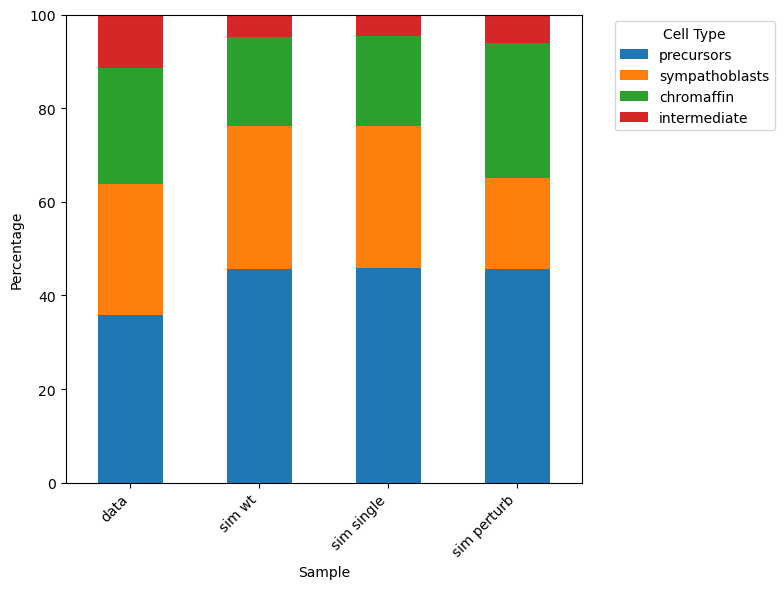

cell_type    precursors  sympathoblasts  chromaffin  intermediate
data          35.722222       28.055556   24.722222     11.500000
sim wt        45.722222       30.500000   18.944444      4.833333
sim single    45.888889       30.388889   19.055556      4.666667
sim perturb   45.666667       19.500000   28.666667      6.166667
📂 Lecture : ./../experimental_datasets/Kameneva/cardamomOT/adata_sim_KO_POSTN_OV_none_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['POSTN']
🔄 Remplacement des valeurs simulées pour POSTN
Avant : mean=3.333, Après : mean=0.509


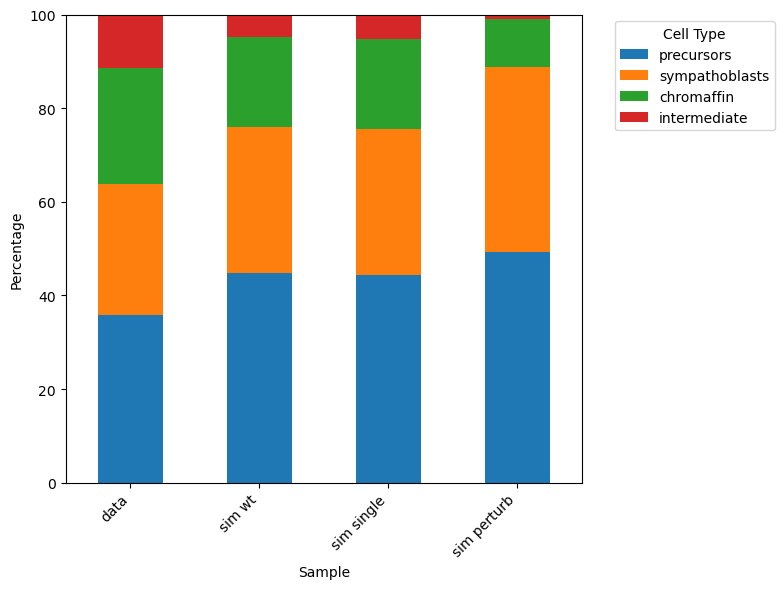

cell_type    precursors  sympathoblasts  chromaffin  intermediate
data          35.722222       28.055556   24.722222     11.500000
sim wt        44.722222       31.277778   19.166667      4.833333
sim single    44.333333       31.277778   19.055556      5.333333
sim perturb   49.166667       39.555556   10.388889      0.888889


In [14]:
compare_cell_types(p_DO,"KO_CHGA_OV_STMN2", train='full')
compare_cell_types(p_DO,"KO_CHGA_OV_none", train='full')
compare_cell_types(p_DO,"KO_none_OV_STMN2", train='full')
compare_cell_types(p_DO,"KO_none_OV_S100B", train='full')
compare_cell_types(p_DO,"KO_none_OV_POSTN", train='full')
compare_cell_types(p_DO,"KO_POSTN_OV_none", train='full')

📂 Lecture : ./../tests/Semrau/cardamomOT/adata_sim_KO_none_OV_Zfp42_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['Zfp42']
🔄 Remplacement des valeurs simulées pour Zfp42
Avant : mean=1.666, Après : mean=5.038


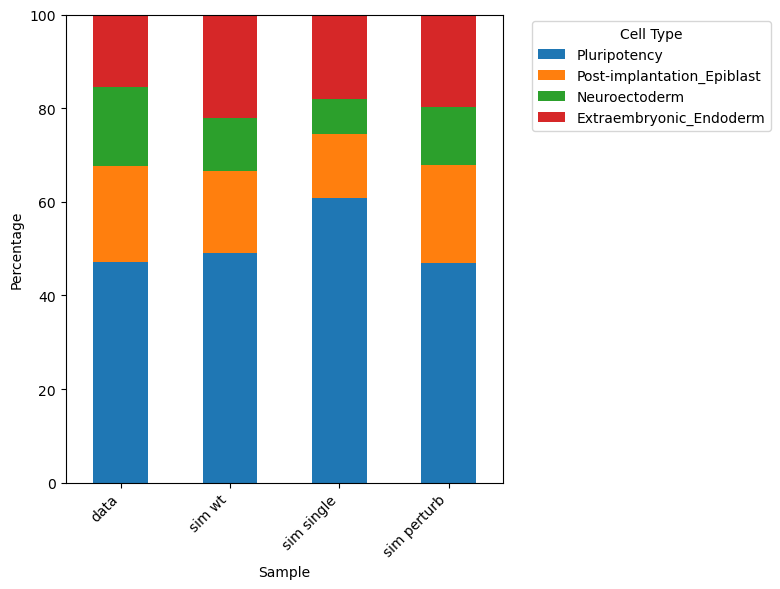

cell_type    Pluripotency  Post-implantation_Epiblast  Neuroectoderm  \
data            47.080441                   20.661494      16.700694   
sim wt          48.953824                   17.604618      11.255411   
sim single      60.714286                   13.672439       7.503608   
sim perturb     46.825397                   21.031746      12.481962   

cell_type    Extraembryonic_Endoderm  
data                       15.557370  
sim wt                     22.186147  
sim single                 18.109668  
sim perturb                19.660895  
📂 Lecture : ./../tests/Semrau/cardamomOT/adata_sim_KO_none_OV_Sox2_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['Sox2']
🔄 Remplacement des valeurs simulées pour Sox2
Avant : mean=1.504, Après : mean=5.567


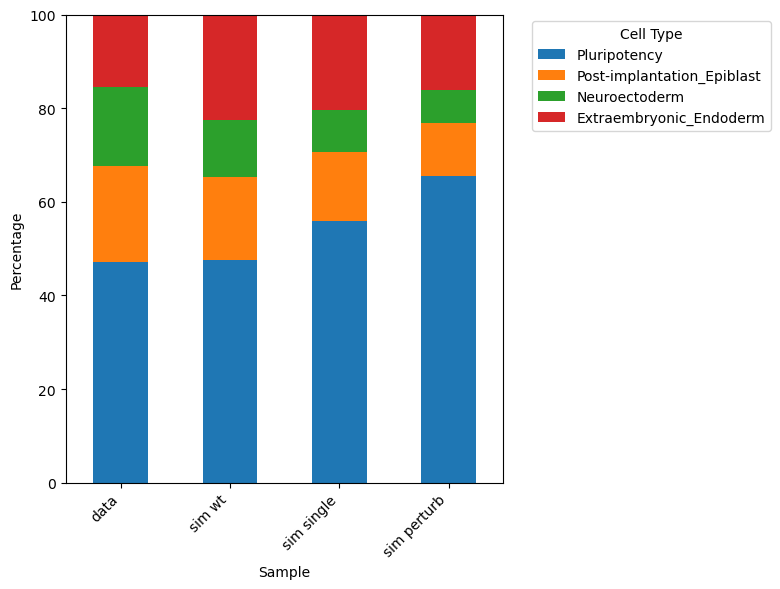

cell_type    Pluripotency  Post-implantation_Epiblast  Neuroectoderm  \
data            47.080441                   20.661494      16.700694   
sim wt          47.546898                   17.784993      12.193362   
sim single      55.808081                   14.718615       9.163059   
sim perturb     65.584416                   11.219336       7.070707   

cell_type    Extraembryonic_Endoderm  
data                       15.557370  
sim wt                     22.474747  
sim single                 20.310245  
sim perturb                16.125541  
📂 Lecture : ./../tests/Semrau/cardamomOT/adata_sim_KO_none_OV_Jarid2_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['Jarid2']
🔄 Remplacement des valeurs simulées pour Jarid2
Avant : mean=1.380, Après : mean=3.399


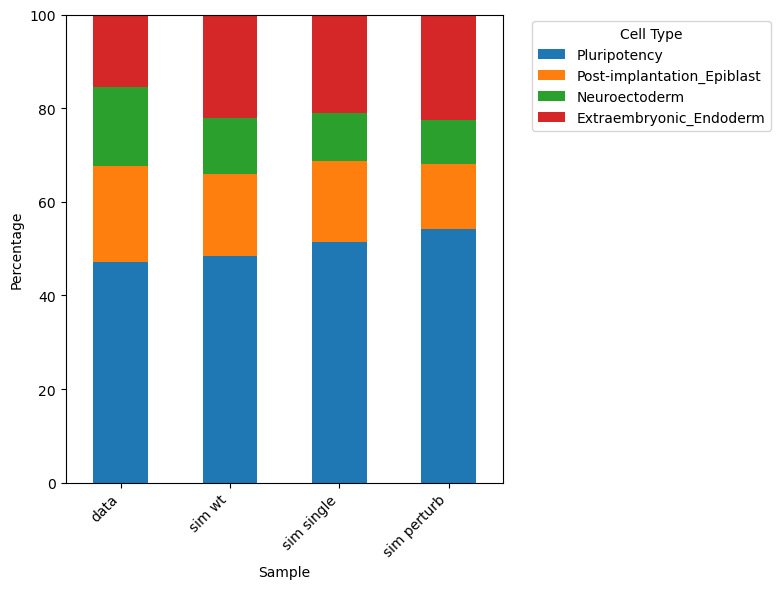

cell_type    Pluripotency  Post-implantation_Epiblast  Neuroectoderm  \
data            47.080441                   20.661494      16.700694   
sim wt          48.448773                   17.388167      12.012987   
sim single      51.406926                   17.352092      10.137085   
sim perturb     54.256854                   13.816739       9.379509   

cell_type    Extraembryonic_Endoderm  
data                       15.557370  
sim wt                     22.150072  
sim single                 21.103896  
sim perturb                22.546898  
📂 Lecture : ./../tests/Semrau/cardamomOT/adata_sim_KO_none_OV_Hoxb2_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['Hoxb2']
🔄 Remplacement des valeurs simulées pour Hoxb2
Avant : mean=0.297, Après : mean=1.947


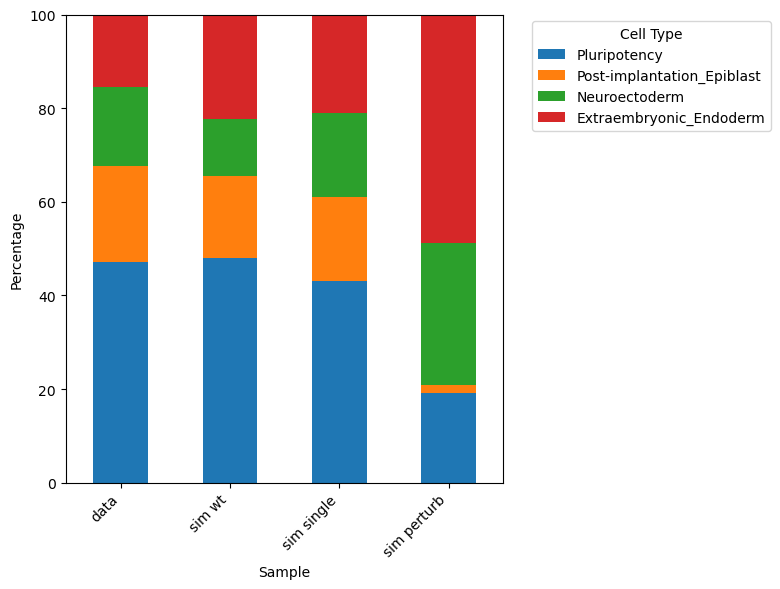

cell_type    Pluripotency  Post-implantation_Epiblast  Neuroectoderm  \
data            47.080441                   20.661494      16.700694   
sim wt          48.088023                   17.496392      12.049062   
sim single      43.037518                   18.073593      17.784993   
sim perturb     19.227994                    1.623377      30.411255   

cell_type    Extraembryonic_Endoderm  
data                       15.557370  
sim wt                     22.366522  
sim single                 21.103896  
sim perturb                48.737374  
📂 Lecture : ./../tests/Semrau/cardamomOT/adata_sim_KO_none_OV_Dnmt3a_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['Dnmt3a']
🔄 Remplacement des valeurs simulées pour Dnmt3a
Avant : mean=0.599, Après : mean=2.373


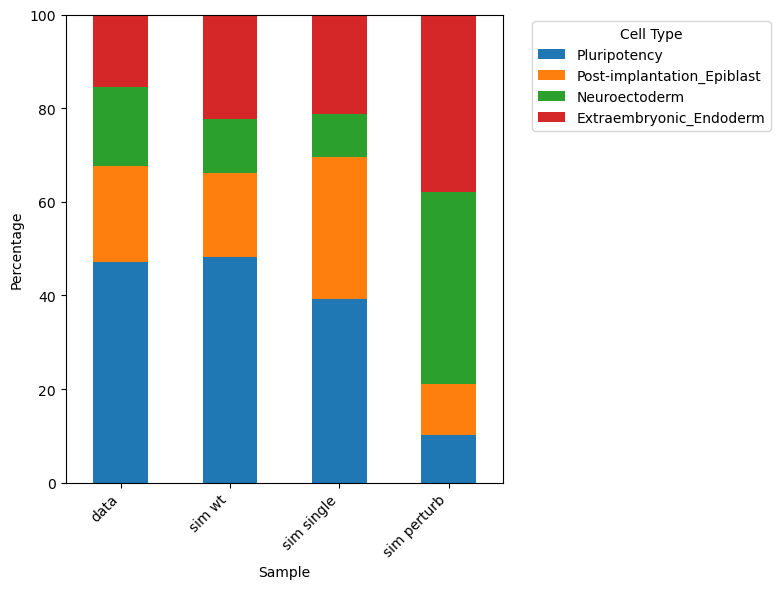

cell_type    Pluripotency  Post-implantation_Epiblast  Neuroectoderm  \
data            47.080441                   20.661494      16.700694   
sim wt          48.268398                   17.821068      11.616162   
sim single      39.213564                   30.447330       8.982684   
sim perturb     10.173160                   11.002886      40.873016   

cell_type    Extraembryonic_Endoderm  
data                       15.557370  
sim wt                     22.294372  
sim single                 21.356421  
sim perturb                37.950938  
📂 Lecture : ./../tests/Semrau/cardamomOT/adata_sim_KO_none_OV_Col4a2_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['Col4a2']
🔄 Remplacement des valeurs simulées pour Col4a2
Avant : mean=0.816, Après : mean=5.246


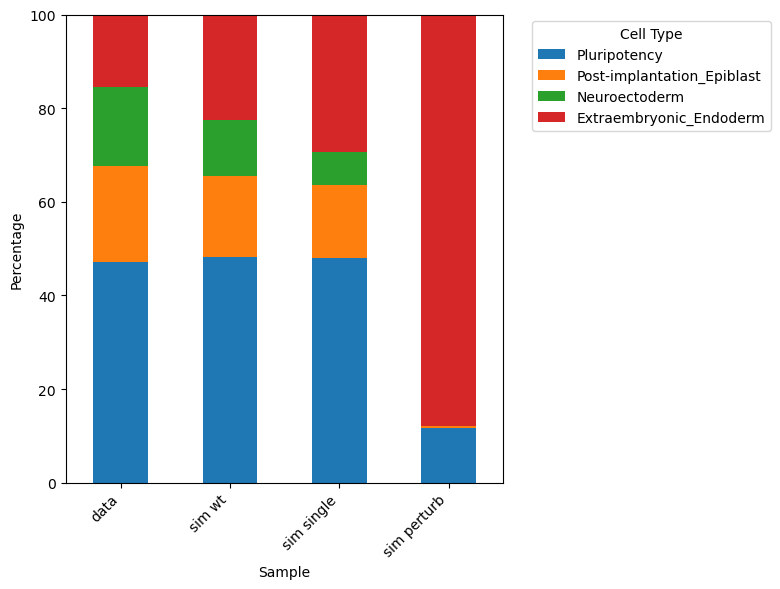

cell_type    Pluripotency  Post-implantation_Epiblast  Neuroectoderm  \
data            47.080441                   20.661494      16.700694   
sim wt          48.124098                   17.388167      12.049062   
sim single      48.051948                   15.584416       6.998557   
sim perturb     11.760462                    0.288600       0.000000   

cell_type    Extraembryonic_Endoderm  
data                       15.557370  
sim wt                     22.438672  
sim single                 29.365079  
sim perturb                87.950938  


In [ ]:
compare_cell_types(p_Sem,"KO_none_OV_Zfp42", train='full')
compare_cell_types(p_Sem,"KO_none_OV_Sox2", train='full')
compare_cell_types(p_Sem,"KO_none_OV_Jarid2", train='full')
compare_cell_types(p_Sem,"KO_none_OV_Hoxb2", train='full')
compare_cell_types(p_Sem,"KO_none_OV_Dnmt3a", train='full')
compare_cell_types(p_Sem,"KO_none_OV_Col4a2", train='full')

📂 Lecture : ./../collaborations/Schiebinger/cardamomOT/adata_sim_KO_none_OV_Obox6-Zfp42_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['Obox6', 'Zfp42']
🔄 Remplacement des valeurs simulées pour Obox6
Avant : mean=0.562, Après : mean=2.337
🔄 Remplacement des valeurs simulées pour Zfp42
Avant : mean=0.648, Après : mean=2.626


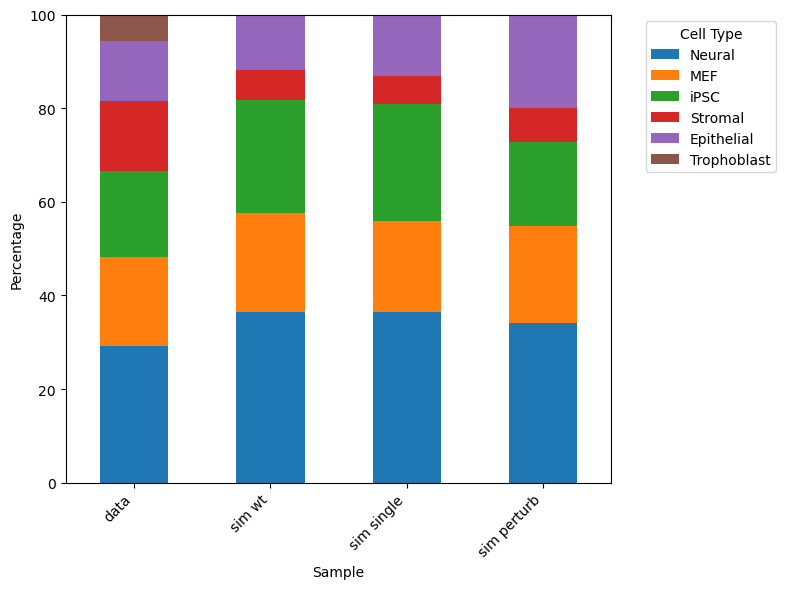

cell_type       Neural        MEF       iPSC    Stromal  Epithelial  \
data         29.168033  19.025765  18.337376  14.980660   12.922048   
sim wt       36.381186  21.310109  24.034749   6.467181   11.530362   
sim single   36.359249  19.559495  24.969287   5.923131   13.013338   
sim perturb  34.082134  20.818708  17.804493   7.410495   19.783257   

cell_type    Trophoblast  
data            5.566118  
sim wt          0.276413  
sim single      0.175500  
sim perturb     0.100913  
📂 Lecture : ./../collaborations/Schiebinger/cardamomOT/adata_sim_KO_none_OV_Obox6_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['Obox6']
🔄 Remplacement des valeurs simulées pour Obox6
Avant : mean=0.562, Après : mean=2.329


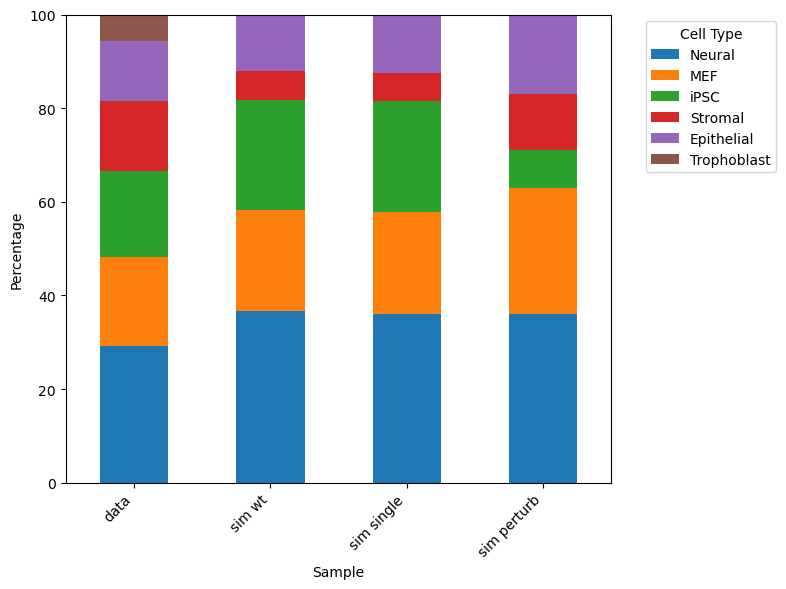

cell_type       Neural        MEF       iPSC    Stromal  Epithelial  \
data         29.168033  19.025765  18.337376  14.980660   12.922048   
sim wt       36.596174  21.608459  23.604774   6.173219   11.679537   
sim single   35.977536  21.735697  23.736399   6.160056   12.048087   
sim perturb  36.082836  26.816427   8.252896  11.960337   16.580379   

cell_type    Trophoblast  
data            5.566118  
sim wt          0.337838  
sim single      0.342225  
sim perturb     0.307125  
📂 Lecture : ./../collaborations/Schiebinger/cardamomOT/adata_sim_KO_none_OV_Zfp42_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['Zfp42']
🔄 Remplacement des valeurs simulées pour Zfp42
Avant : mean=0.648, Après : mean=2.654


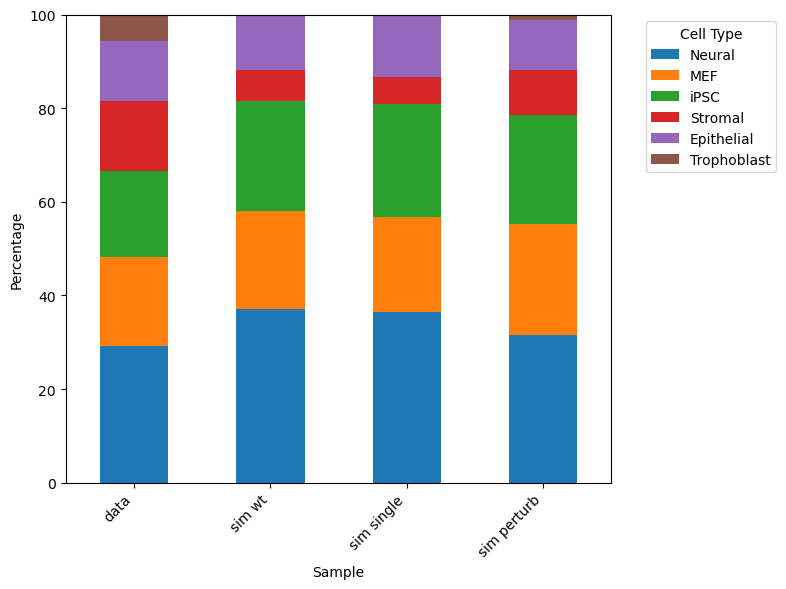

cell_type       Neural        MEF       iPSC    Stromal  Epithelial  \
data         29.168033  19.025765  18.337376  14.980660   12.922048   
sim wt       37.096350  20.941558  23.582836   6.550544   11.521587   
sim single   36.438224  20.217620  24.201474   5.852931   13.044051   
sim perturb  31.445244  23.797824  23.323973   9.542822   10.780098   

cell_type    Trophoblast  
data            5.566118  
sim wt          0.307125  
sim single      0.245700  
sim perturb     1.110039  


In [ ]:
compare_cell_types(p_S,"KO_none_OV_Obox6-Zfp42")
compare_cell_types(p_S,"KO_none_OV_Obox6")
compare_cell_types(p_S,"KO_none_OV_Zfp42")

In [11]:
compare_cell_types(p_v3,"KO_COL6A1_OV_none")
compare_cell_types(p_v3,"KO_none_OV_COL6A1")
compare_cell_types(p_v3,"KO_SERPINE2_OV_none")
compare_cell_types(p_v3,"KO_none_OV_SERPINE2")
compare_cell_types(p_v3,"KO_BIRC5_OV_none")
compare_cell_types(p_v3,"KO_none_OV_BIRC5")

📂 Lecture : ./../collaborations/copycat/RMS2V3/cardamomOT/adata_sim_KO_COL6A1_OV_none_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['COL6A1']
🔄 Remplacement des valeurs simulées pour COL6A1
Avant : mean=1.995, Après : mean=0.420


ValueError: could not broadcast input array from shape (8196,) into shape (8376,)

In [ ]:
compare_cell_types(p_all,"KO_HSPA1B_OV_none")
compare_cell_types(p_all,"KO_none_OV_HSPA1B")
compare_cell_types(p_all,"KO_SERPINE2_OV_none")
compare_cell_types(p_all,"KO_none_OV_SERPINE2")
compare_cell_types(p_all,"KO_COL6A2_OV_none")
compare_cell_types(p_all,"KO_none_OV_COL6A2")

📂 Lecture : ./../collaborations/copycat/RD136/cardamomOT/adata_sim_KO_HSPA1B_OV_none_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['HSPA1B']
🔄 Remplacement des valeurs simulées pour HSPA1B
Avant : mean=2.870, Après : mean=0.353


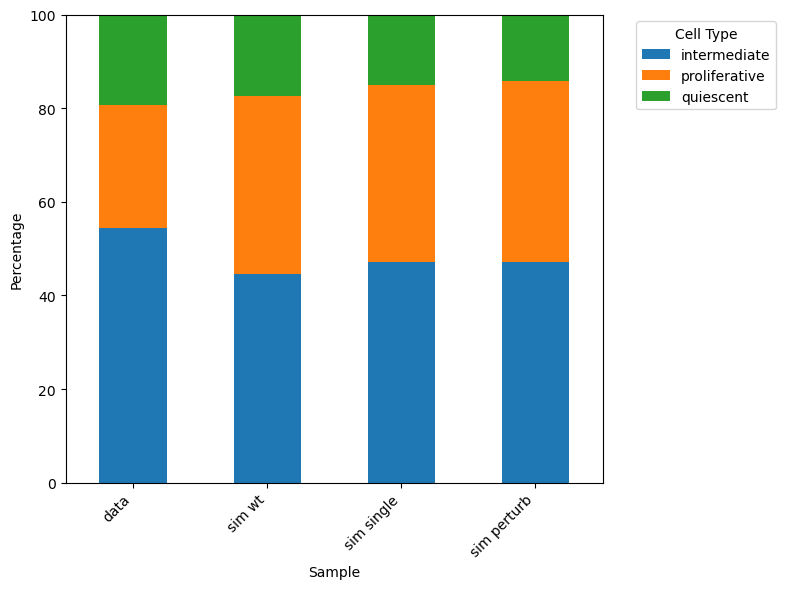

cell_type    intermediate  proliferative  quiescent
data            54.303932      26.381509  19.314559
sim wt          44.665605      37.871550  17.462845
sim single      47.027601      37.898089  15.074310
sim perturb     47.027601      38.773885  14.198514
📂 Lecture : ./../collaborations/copycat/RD136/cardamomOT/adata_sim_KO_none_OV_HSPA1B_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['HSPA1B']
🔄 Remplacement des valeurs simulées pour HSPA1B
Avant : mean=2.870, Après : mean=6.578


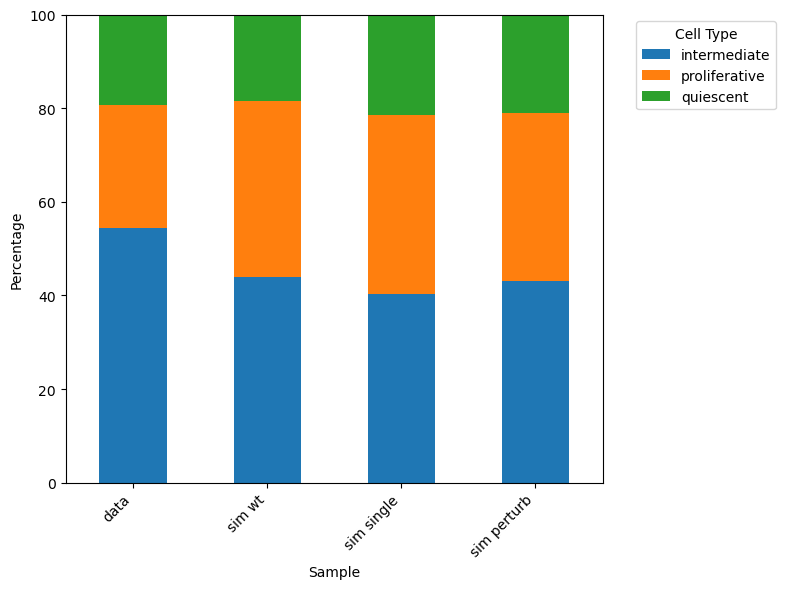

cell_type    intermediate  proliferative  quiescent
data            54.303932      26.381509  19.314559
sim wt          43.922505      37.606157  18.471338
sim single      40.392781      38.190021  21.417197
sim perturb     43.126327      35.828025  21.045648
📂 Lecture : ./../collaborations/copycat/RD136/cardamomOT/adata_sim_KO_SERPINE2_OV_none_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['SERPINE2']
🔄 Remplacement des valeurs simulées pour SERPINE2
Avant : mean=3.355, Après : mean=0.032


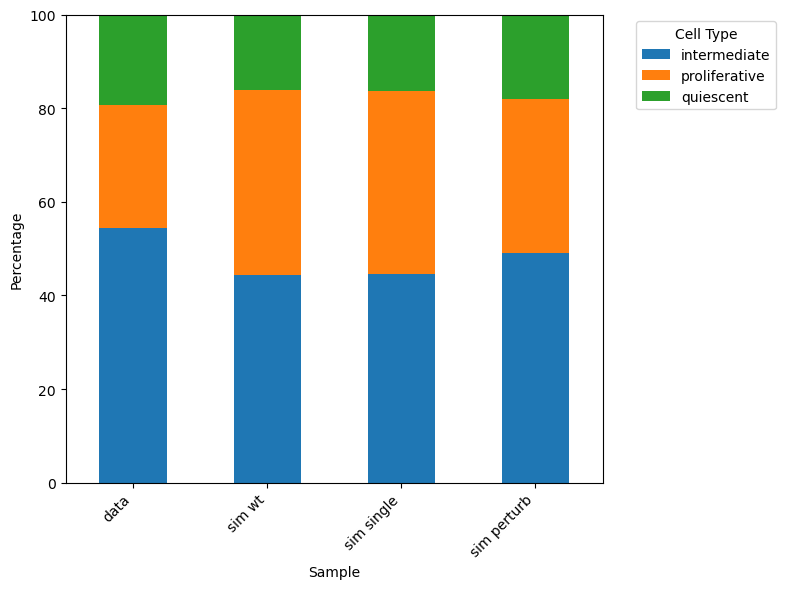

cell_type    intermediate  proliferative  quiescent
data            54.303932      26.381509  19.314559
sim wt          44.453291      39.357749  16.188960
sim single      44.479830      39.278132  16.242038
sim perturb     49.071125      32.776008  18.152866
📂 Lecture : ./../collaborations/copycat/RD136/cardamomOT/adata_sim_KO_none_OV_SERPINE2_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['SERPINE2']
🔄 Remplacement des valeurs simulées pour SERPINE2
Avant : mean=3.355, Après : mean=3.857


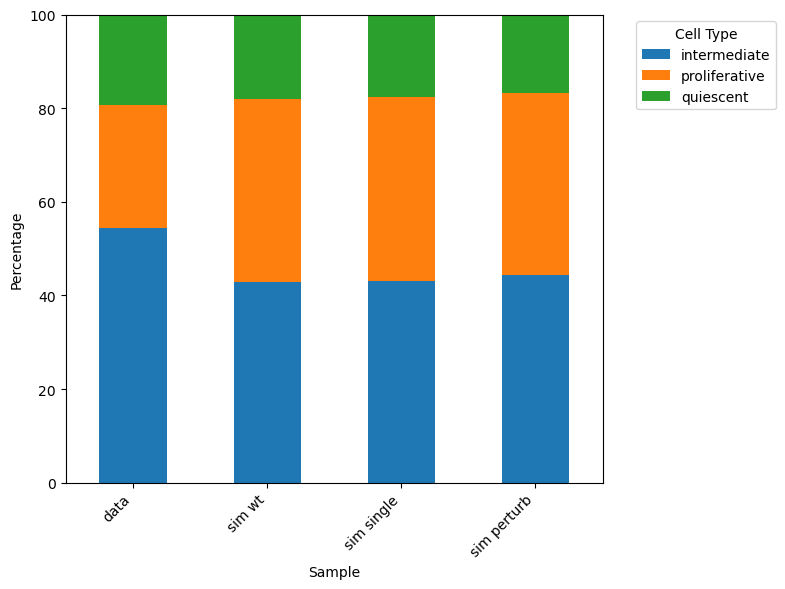

cell_type    intermediate  proliferative  quiescent
data            54.303932      26.381509  19.314559
sim wt          42.834395      39.198514  17.967091
sim single      43.046709      39.225053  17.728238
sim perturb     44.347134      38.933121  16.719745


In [ ]:
compare_cell_types(p_136,"KO_HSPA1B_OV_none")
compare_cell_types(p_136,"KO_none_OV_HSPA1B")
compare_cell_types(p_136,"KO_SERPINE2_OV_none")
compare_cell_types(p_136,"KO_none_OV_SERPINE2")

📂 Lecture : ./../collaborations/copycat/RMS10/cardamomOT/adata_sim_KO_COL6A1_OV_none_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['COL6A1']
🔄 Remplacement des valeurs simulées pour COL6A1
Avant : mean=32.449, Après : mean=6.232


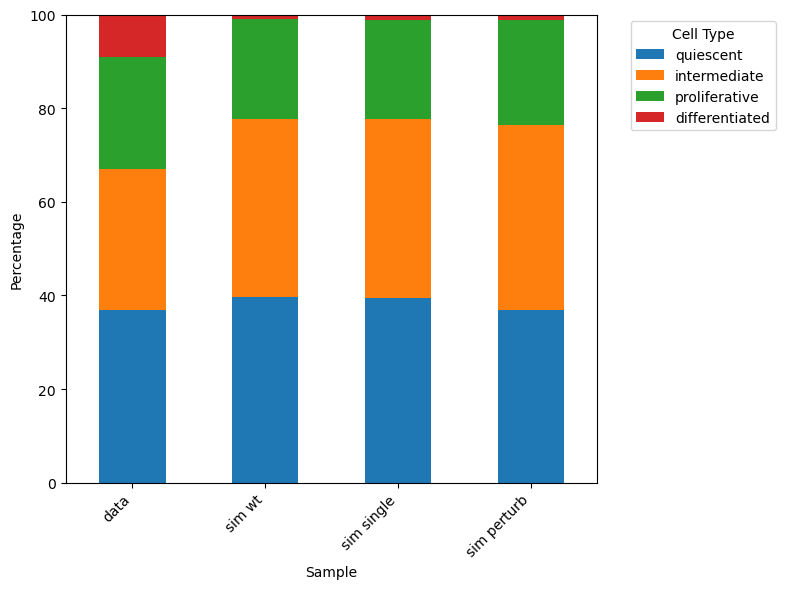

cell_type    quiescent  intermediate  proliferative  differentiated
data         36.827957     30.261137      23.732719        9.178187
sim wt       39.708141     37.864823      21.390169        1.036866
sim single   39.439324     38.172043      21.198157        1.190476
sim perturb  36.789555     39.516129      22.427035        1.267281
📂 Lecture : ./../collaborations/copycat/RMS10/cardamomOT/adata_sim_KO_none_OV_COL6A1_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['COL6A1']
🔄 Remplacement des valeurs simulées pour COL6A1
Avant : mean=32.449, Après : mean=136.003


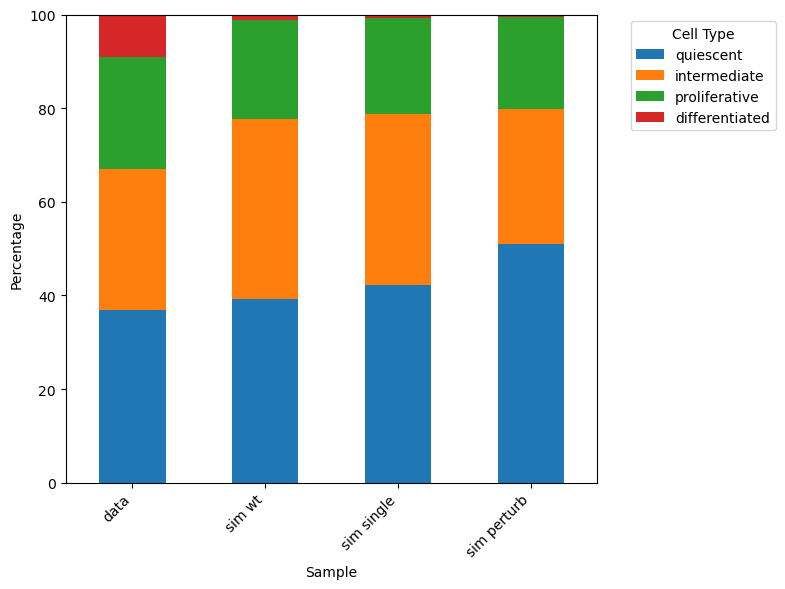

cell_type    quiescent  intermediate  proliferative  differentiated
data         36.827957     30.261137      23.732719        9.178187
sim wt       39.208909     38.402458      21.159754        1.228879
sim single   42.165899     36.520737      20.468510        0.844854
sim perturb  50.998464     28.801843      19.738863        0.460829
📂 Lecture : ./../collaborations/copycat/RMS10/cardamomOT/adata_sim_KO_COL6A2_OV_none_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['COL6A2']
🔄 Remplacement des valeurs simulées pour COL6A2
Avant : mean=13.395, Après : mean=2.836


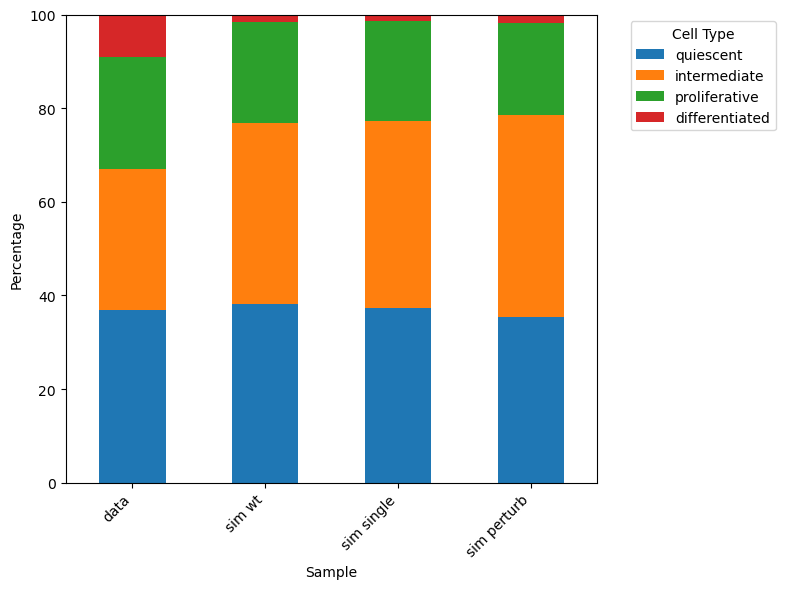

cell_type    quiescent  intermediate  proliferative  differentiated
data         36.827957     30.261137      23.732719        9.178187
sim wt       38.248848     38.594470      21.543779        1.612903
sim single   37.288786     39.976959      21.351767        1.382488
sim perturb  35.483871     43.049155      19.623656        1.843318
📂 Lecture : ./../collaborations/copycat/RMS10/cardamomOT/adata_sim_KO_none_OV_COL6A2_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['COL6A2']
🔄 Remplacement des valeurs simulées pour COL6A2
Avant : mean=13.395, Après : mean=42.289


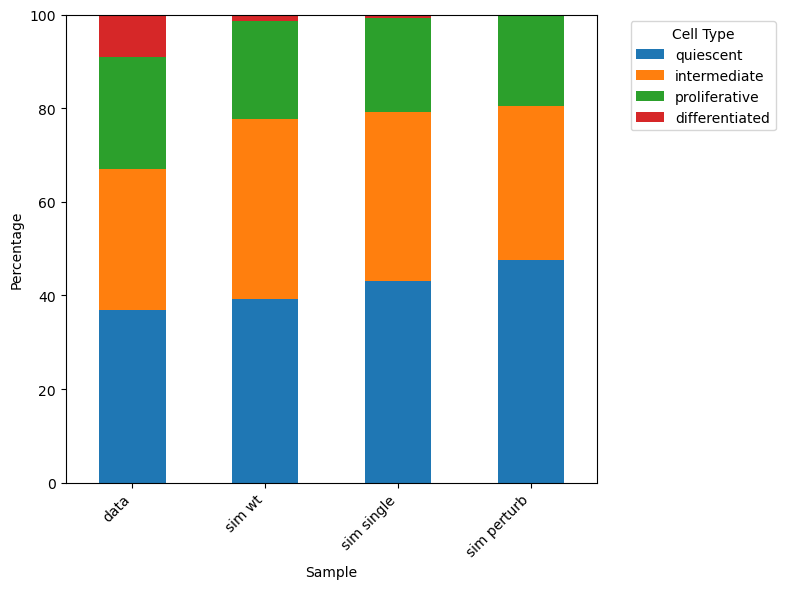

cell_type    quiescent  intermediate  proliferative  differentiated
data         36.827957     30.261137      23.732719        9.178187
sim wt       39.132104     38.556068      21.006144        1.305684
sim single   43.049155     36.175115      20.007680        0.768049
sim perturb  47.657450     32.834101      19.393241        0.115207
📂 Lecture : ./../collaborations/copycat/RMS10/cardamomOT/adata_sim_KO_COL6A3_OV_none_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['COL6A3']
🔄 Remplacement des valeurs simulées pour COL6A3
Avant : mean=37.107, Après : mean=1.872


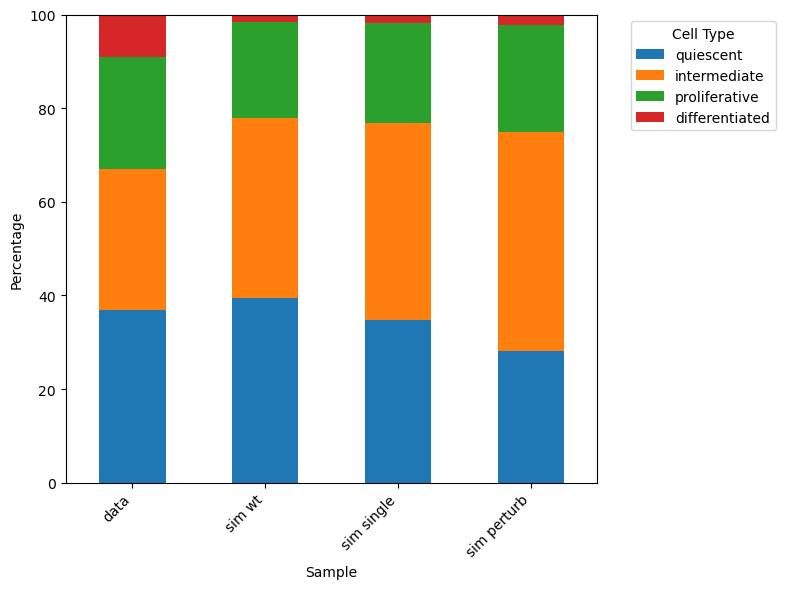

cell_type    quiescent  intermediate  proliferative  differentiated
data         36.827957     30.261137      23.732719        9.178187
sim wt       39.400922     38.479263      20.506912        1.612903
sim single   34.715822     42.012289      21.543779        1.728111
sim perturb  28.225806     46.582181      22.926267        2.265745
📂 Lecture : ./../collaborations/copycat/RMS10/cardamomOT/adata_sim_KO_none_OV_COL6A3_stim1.0_prior1.0.h5ad
🧬 Gènes perturbés détectés : ['COL6A3']
🔄 Remplacement des valeurs simulées pour COL6A3
Avant : mean=37.107, Après : mean=124.630


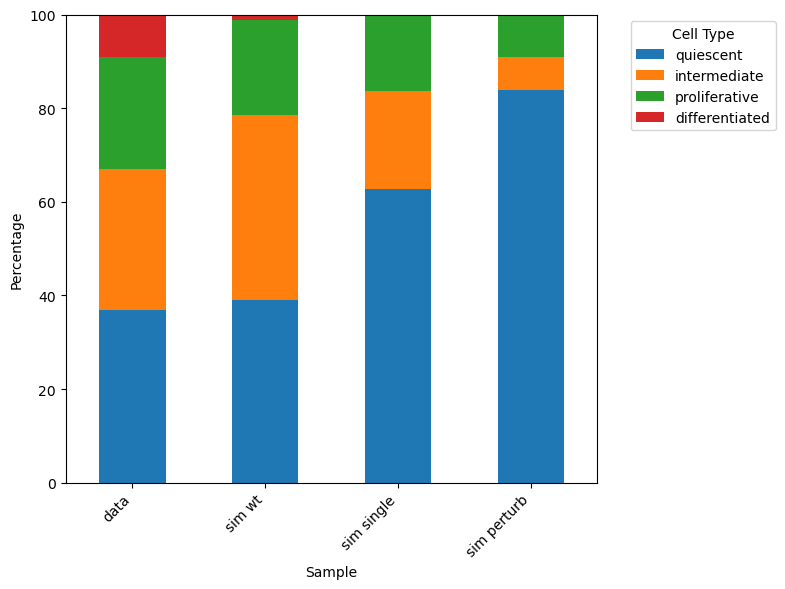

cell_type    quiescent  intermediate  proliferative  differentiated
data         36.827957     30.261137      23.732719        9.178187
sim wt       39.055300     39.477727      20.199693        1.267281
sim single   62.711214     20.890937      16.397849        0.000000
sim perturb  83.947773      7.066052       8.986175        0.000000


In [ ]:
compare_cell_types(p_10,"KO_COL6A1_OV_none")
compare_cell_types(p_10,"KO_none_OV_COL6A1")
compare_cell_types(p_10,"KO_COL6A2_OV_none")
compare_cell_types(p_10,"KO_none_OV_COL6A2")
compare_cell_types(p_10,"KO_COL6A3_OV_none")
compare_cell_types(p_10,"KO_none_OV_COL6A3")

